# Vácuo Quântico

* PET Física - UFRN
* Petiano: Wallysson Pereira da Silva
* Data: 24/04/2026 

$\quad$ Neste projeto estaremos utilizando um resultado bem interessante da Teoria Quântica de Campos para simular o comportamento do vácuo. Como será desenvolvido mais adiante, esse resultado nos indica que o vácuo não é totalmente isento de energia, ainda há pequenas flutuações, que visualizaremos através de plots. Com isso em mente, esse 'notebook' foi dividido nas seguintes seções 

1. Introdução Teórica;

2. Visualização estática;

3. Evolução temporal

4. Função de correlação

5. Conclusão.

## Importando bibliotecas

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import kn # Função de Bessel para a curva teórica
import matplotlib.animation as animation

## Informações sobre as bibliotecas

In [18]:
%load_ext version_information
%version_information Matplotlib, Numpy

The version_information extension is already loaded. To reload it, use:
  %reload_ext version_information


Software versions
Python 3.13.0 64bit [MSC v.1941 64 bit (AMD64)]
IPython 8.29.0
OS Windows 11 10.0.26200 SP0
Matplotlib 3.9.2
Numpy 2.1.3
Mon Apr 20 11:11:49 2026 Hora Padrão de Buenos Aires

## 1. Introdução Teórica

$\quad$ A existÊncia do vácuo sempre foi uma questão filosófica bem relevante em diversas sociedades. Na própria cultura grega relacionava-se a ideia de vácuo, entendida como a ausência total de matéria, com a existência do movimento. Dentro do mundo grego antigo, apesar das divergências entre os ditos eleatas e os atomistas sobre a existência ou não de vácuo, ambos concordavam que se ele existesse, o movimento existiria. Mais tarde, Aristóteles estabeleceu que a natureza tenderia naturalmente a preencher os espaços vázios que surgissem, logo impossibilitando a existência do vácuo.      

$\quad$ A noção cotidiana atual sobre o fato, isto é, a de ausência absoluta de matéria e energia, vai de encontro direto à interpretação da física clássica. Assim, imaginamos que seria possível pegar uma caixa, retirar todas as partículas, isolá-la completamente do ambiente externo, restando tão somente o absoluto nada dentro da caixa. No entando, a Teoria Quântica de Campos (QTF) propôs de maneira satisfatória que essa visão está incompleta. O vácuo não é apenas um palco vazio, mas sim um meio com bastante dinâmico e com glamurosa ação. Nesse 'notebook' (AJEITAR), simularemos o comportamento do campo escalar de Klein-Gordon, o modelo mais simples da teoria de campos.

$\quad$ Dentro do contexto do campo escalar de Klein-Gordon, buscaremos simular o estado de menor energia possível: o estado de vácuo. Para tal, é importante destacar que a QTF abandona a ideia de um universo feito de entidades físicas isoladas, ao passo eleva o campo ao patamar de bloco fundamental da natureza. Pense num campo como uma entidade que permeia todo o espaço (e o tempo), de forma contínua por toda a sua extensão. O exemplo mais comúm seria o de campo de temperatura. 

$\quad$ Nesse contexto de campos permeando todo o espaço, o que nos antes conhecíamos como "partícula", agora é apenas uma ondulação ou excitacação empacotada viajando através desse campo. Sob esse paradigma, poderíamos pensar que o vácuo seria representado por um campo totalmente plano e imóvel, com energia zero. No entando, fazendo jus à parte "quântica" da QTF, o Princípio da Incerteza de Heisenberg proíbe essa estaticidade absoluta. Assim como não podemos saber a posição e a velocidade de um elétron ao mesmo tempo, não podemos fixar o valor do campo e sua taxa de variação simultaneamente. Como resultado, o campo sofre oscilações probabilísticas contínuas, criando minúsculas ondas de energia que aparecem e desaparecem quase instantaneamente. Essas são as chamadas Flutuações de Vácuo 

$\quad$ Para simular esse mar quântico computacionalmente, utilizamos a matemática da quantização canônica. Nesse paradigma físico, os campos $\phi(x)$ e sua densidade de momento $\Pi^{0}(x)$ são promovidos a operadores: $\phi(x) \to \hat{\phi}(x)$ e $\Pi^{0}(x) \to \hat{\Pi}^{0}(x)$. Junto com isso, impomos relações de comutações entre esses dois entes matemáticos. Por exemplo, 
$[\hat{\phi}(t,x),\hat{\Pi}^{0}(t,x)] = i\delta^{(3)}(x-y),$ onde avaliamos os campos num mesmo instante de tempo. Assim como muito bem abordado na referência **[1]**, nos podemos expressar o operador campo em função dos operadores de criação e aniquilação ($\hat{a}$ e $\hat{a}^{\dagger}$, respectivamente):
$$
\hat{\phi}(x) = \int \frac{d^{3}p}{(2\pi)^{\frac{3}{2}}}\frac{1}{\sqrt{2\omega_p}}\left (\hat{a}_pe^{i\textbf{p}\cdot \textbf{x}} + \hat{a}_{p}^{\dagger}e^{-i\textbf{p}\cdot \textbf{x}}  \right),
$$ 
onde estamos trabalhando no sistema de unidades naturais, com energia tendo a mesmoa dimensão de frequência.

$\quad$ Podemos argumentar que, como operador de aniquilação $\hat{a}_p$ atua diminuindo uma quantidade $w_p$ do modo de oscilação $p$, para previnir instabilidades que levariam à divergências no sistema, deve existir um estado $\ket{0}$ tal que $\hat{a}^{p}\ket{0} = 0$ para todo $p$. Usando esse argumento, e a partir da forma explícita de $\hat{a}_{p}$ em função dos operadores campos ($\hat{\phi}_{p}(x)$ e $\hat{\Pi}_{p}$)  
$
\hat{a}_p = \sqrt{\frac{\omega_p}{2}}\hat{\phi}_p + i\frac{2}{\sqrt{2\omega_p}}\hat{\Pi}, 
$
é possível chegar na forma do estado do vácuo, utilizando a representação dentro do espaço das configurações do campo:
$$
\langle 0 | \phi \rangle = \Psi_0{[\phi]} = \mathcal{N}\exp{\left(-\frac{1}{2}\int d^{3}p \ \omega_p |\phi_p|^2\right)},
\tag{1}
$$
com $\mathcal{N}$ sendo apenas uma constante de normalização. Dessa expressão já tiramos algumas uma consideração importante: o vácuo tem um comportamento gaussiano. 

Partindo pra interpretação estatística desse estado, temos que a probabilidade de encontrarmos o vácuo flutuando com uma determinada configuração de campo $\psi$ é
$$
\mathcal{P}[\phi] \propto \left( -\int d^{3}p \ \omega_p |\phi|^2\right).
$$
Derivado desse fato, que a veriância para um dado modo $p$ é proporcional a $\frac{1}{\omega_p}$.

## 2. Visualização estática 

$\quad$ Utilizando todo esse ferramental desenvolvido, vamos agora partir para a simulação. Primeiramente vamos definir as constantes da nossa simulação.

In [19]:
# --- 1. Parâmetros da Simulação ---
N = 512        # Tamanho da grade (512x512 pixels). Quanto maior, mais resolução.
L = 10.0       # Tamanho físico do nosso "pedaço de universo"
m = 1.0        # Massa da partícula do campo (evita divisão por zero)

$\quad$ Na física analítica, o espaço é contínuo e infinito. No computador, precisamos de uma grade finita e discreta. A função np.fft.fftfreq que utilizaremos gera as frequências espaciais permitidas nessa nossa grade de tamanho $N \times N$. Físicamente, estamos definindo todos os vetores de onda $\vec{k}$ (ou momentos, já que $\hbar=1$) possíveis que cabem na nossa "caixa" de simulação de tamanho $L$. A função np.meshgrid cruza essas frequências para criar um plano 2D de momentos, permitindo analisar ondas se propagando em qualquer direção.

In [20]:
# Aqui definimos as frequências (ondas) possíveis na nossa grade
kx = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
ky = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky)

$\quad$ Agora vamos calcular a energia de cada modo do campo. Essa linha é a implementação direta da relação de dispersão da relatividade restrita no sistema de unidades naturais ($c=1$):$$\omega_k = \sqrt{|\vec{k}|^2 + m^2}$$Para cada "pixel" no nosso espaço de momentos (uma onda específica), calculamos o seu custo energético $\omega_k$. O termo da massa $m$ garante que até as ondas de momento zero tenham uma energia mínima (evitando divisões por zero nas próximas etapas e modelando um campo massivo).

In [21]:
# A relação de dispersão: omega_k = sqrt(|k|^2 + m^2)
omega_k = np.sqrt(KX**2 + KY**2 + m**2)

Lembra que provamos que o vácuo quântico é ditado por um funcional de probabilidade Gaussiano? É exatamente isso que a função np.random.normal(0, 1) faz. Como os operadores $\hat{a}$ e $\hat{a}^\dagger$ não comutam, o valor do campo flutua aleatoriamente em torno do zero. Construímos um ruído branco complexo sorteando valores de uma distribuição normal para simular o comportamento probabilístico desses operadores para cada frequência isolada do nosso universo simulado.

In [22]:
# --- 4. Gerar o "Ruído Quântico" ---

# Simulamos os operadores de criação/aniquilação como números complexos aleatórios.
# Eles seguem uma distribuição normal (Gaussiana).
ruido_real = np.random.normal(0, 1, (N, N))
ruido_imag = np.random.normal(0, 1, (N, N))
a_k = (ruido_real + 1j * ruido_imag) / np.sqrt(2)

Esta é a alma matemática da quantização! Da expansão canônica do campo, sabemos que a amplitude de flutuação de cada modo no vácuo é modulada pela sua energia. A linha de código implementa o fator:$$\frac{1}{\sqrt{2\omega_k}}$$Isso significa que dividimos o nosso ruído quântico puramente aleatório pela raiz da energia daquela onda. Fisicamente, isso diz que ondas de alta frequência (alta energia) flutuam muito pouco, enquanto ondas de baixa frequência flutuam com amplitudes muito maiores. É essa modulação que transforma um simples ruído branco de computador na textura física de um campo quântico.

In [23]:
# --- 5. A Equação do Campo ---
# Modulamos o ruído pela energia
phi_k = a_k / np.sqrt(2 * omega_k)

Até o passo anterior, nós tínhamos o campo descrito no espaço das frequências (momentos). A Transformada Inversa Rápida de Fourier 2D (np.fft.ifft2) faz a integral que soma todas essas infinitas ondas $\phi_k$, cada uma com sua fase e amplitude corretas, e as colapsa de volta para o espaço real. Como o campo escalar de Klein-Gordon descreve partículas neutras, o campo deve ser um valor real (um operador Hermitiano). Pegamos a parte real (np.real) apenas para descartar resíduos numéricos imaginários ínfimos que surgem do cálculo flutuante do computador.

In [24]:
# --- 6. Transformada Inversa de Fourier (IFFT) ---

# Pegamos as ondas no espaço dos momentos e transformamos no campo físico no espaço real.
phi_x = np.fft.ifft2(phi_k)

Esta etapa final pega nossa matriz matemática resultante e a transforma em uma imagem (um heatmap). O mapa de cores magma não está mostrando calor, mas sim os picos (positivos) e vales (negativos) das flutuações do campo $\phi(x)$ no espaço. Você está literalmente "fotografando" a manifestação visual do estado fundamental $|0\rangle$, visualizando as partículas virtuais fervilhando no vácuo simulado.

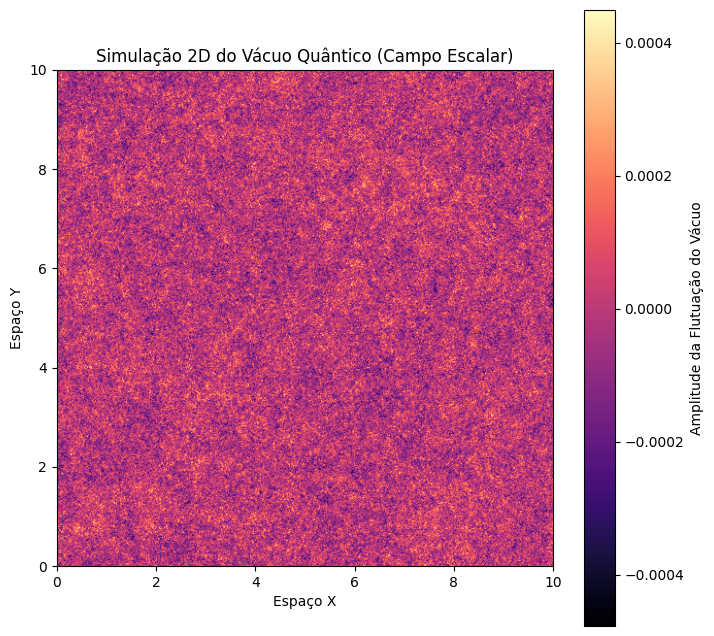

In [25]:
# O campo escalar físico é a parte real do resultado
campo_fisico = np.real(phi_x)

# --- 7. Visualização Inicial do Vácuo ---
plt.figure(figsize=(8, 8))
plt.imshow(campo_fisico, cmap='magma', extent=[0, L, 0, L])
plt.colorbar(label='Amplitude da Flutuação do Vácuo')
plt.title('Simulação 2D do Vácuo Quântico (Campo Escalar)')
plt.xlabel('Espaço X')
plt.ylabel('Espaço Y')
plt.show()



## 3. Função de Correlação

Na Teoria Quântica de Campos, a função de correlação espacial em tempos iguais $\langle \phi(0)\phi(r) \rangle$ é simplesmente a Transformada de Fourier do espectro de potência do vácuo. Como você bem modelou no seu código, a amplitude do campo depende de $\frac{1}{\sqrt{\omega_k}}$, logo o espectro de potência é proporcional a $\frac{1}{\omega_k}$.A matemática nos diz que a correlação é calculada pela integral:$$\langle \phi(0)\phi(r) \rangle \propto \int \frac{d^d k}{(2\pi)^d} \frac{1}{\sqrt{|\vec{k}|^2 + m^2}} e^{i \vec{k} \cdot \vec{r}}$$

### Autocorrelação 2D (Heatmap)

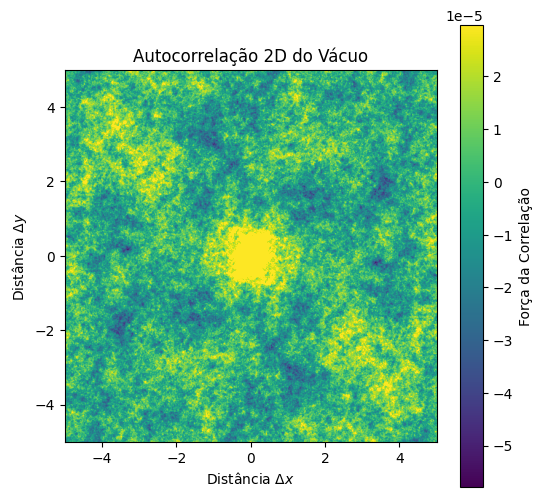

In [26]:
# --- 6. Transformada Inversa de Fourier (IFFT) ---
# Pegamos as ondas no espaço dos momentos e transformamos no campo físico no espaço real.
phi_x = np.fft.ifft2(phi_k)

# --- Autocorrelação 2D ---
espectro_potencia = np.abs(phi_k)**2
espectro_potencia[0, 0] = 0 

autocorr_2d = np.real(np.fft.ifft2(espectro_potencia))
autocorr_2d = np.fft.fftshift(autocorr_2d)

# --- Plot Heatmap ---
plt.figure(figsize=(6, 6))

vmax_corte = np.percentile(autocorr_2d, 98)
plt.imshow(
    autocorr_2d,
    cmap='viridis',
    extent=[-L/2, L/2, -L/2, L/2],
    vmax=vmax_corte
)

plt.title('Autocorrelação 2D do Vácuo')
plt.xlabel(r'Distância $\Delta x$')
plt.ylabel(r'Distância $\Delta y$')
plt.colorbar(label='Força da Correlação')

plt.show()

### Plot da correlação radial vs teoria 

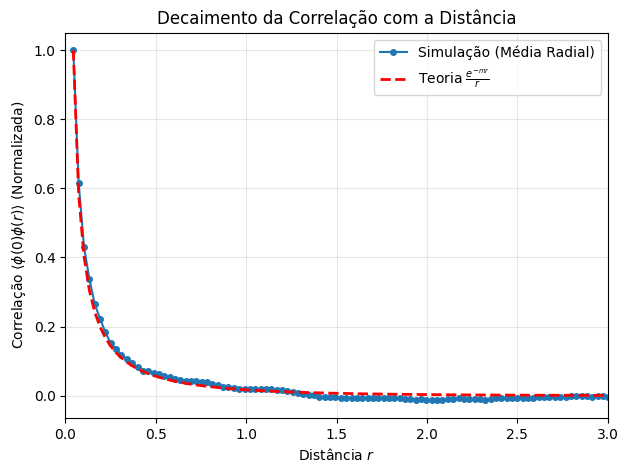

In [34]:
# --- Construção da média radial ---
x = np.arange(-N//2, N//2) * (L/N)
y = np.arange(-N//2, N//2) * (L/N)
XX, YY = np.meshgrid(x, y)
R = np.sqrt(XX**2 + YY**2)

R_flat = R.flatten()
autocorr_flat = autocorr_2d.flatten()

bins = np.linspace(0, L/2, int(N/3))
bin_centers = 0.5 * (bins[1:] + bins[:-1])
radial_corr = np.zeros_like(bin_centers)

for i in range(len(bin_centers)):
    mask = (R_flat >= bins[i]) & (R_flat < bins[i+1])
    if np.any(mask):
        radial_corr[i] = np.mean(autocorr_flat[mask])

# --- Normalização ---
r_valido = bin_centers[1:]
corr_sim = radial_corr[1:]
corr_sim = corr_sim / corr_sim[0]

# --- Curva teórica ---
corr_teorica = np.exp(-m*r_valido)/r_valido
corr_teorica = corr_teorica / corr_teorica[0]

# --- Plot ---
plt.figure(figsize=(7, 5))

plt.plot(r_valido, corr_sim, 'o-', label='Simulação (Média Radial)', markersize=4)
plt.plot(r_valido, corr_teorica, 'r--', label=r'Teoria $\frac{e^{-mr}}{r}$', linewidth=2)

plt.title('Decaimento da Correlação com a Distância')
plt.xlabel('Distância $r$')
plt.ylabel(r'Correlação $\langle \phi(0)\phi(r) \rangle$ (Normalizada)')
plt.xlim(0, 3.0)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## 4. Evolução Temporal

Parâmetros

In [28]:
# --- 1. Parâmetros da Simulação ---
frames = 60    # Número de quadros da animação
dt = 0.1       # Tamanho do passo de tempo entre os quadros

# Modulamos pela energia (o termo 1 / sqrt(2 * omega_k))
phi_k_inicial = phi_k.copy()

Para criar um vídeo, o matplotlib exige que preparemos um "palco" inicial. Criamos a figura e plotamos o estado do campo no instante $t=0$ (exatamente o mesmo campo estático que geramos na Parte 1). A variável im_ani armazena a matriz de cores da imagem, que será substituída repetidamente a cada quadro da nossa animação sem precisarmos redesenhar os eixos e o título todas as vezes.

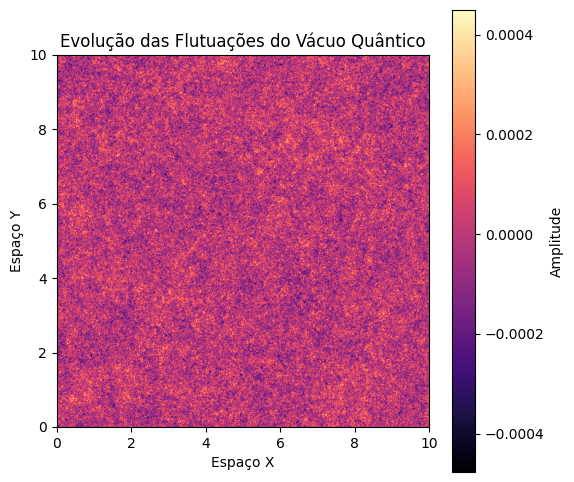

In [29]:
# --- 4. Preparar a Animação ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title("Evolução das Flutuações do Vácuo Quântico")
ax.set_xlabel("Espaço X")
ax.set_ylabel("Espaço Y")

# Geramos o primeiro quadro no tempo t=0 para inicializar a imagem
campo_t0 = np.real(np.fft.ifft2(phi_k_inicial))
im = ax.imshow(campo_t0, cmap='magma', extent=[0, L, 0, L], animated=True)
fig.colorbar(im, ax=ax, label='Amplitude')


In [30]:
# --- 5. Função de Atualização (O motor do tempo) ---
def update(frame):
    t = frame * dt
    
    # A MÁGICA DO TEMPO: Multiplicamos a amplitude inicial pela fase e^{-i * omega_k * t}
    fase_temporal = np.exp(-1j * omega_k * t)
    phi_k_t = phi_k_inicial * fase_temporal
    
    # Transformada inversa para voltar ao espaço real
    campo_fisico_t = np.real(np.fft.ifft2(phi_k_t))
    
    # Atualiza os dados da imagem
    im.set_array(campo_fisico_t)
    
    # Mantém o contraste dinâmico ajustado
    im.set_clim(vmin=np.min(campo_fisico_t), vmax=np.max(campo_fisico_t))
    return [im]

In [31]:
# --- 6. Gerar e Salvar o GIF ---
print("Gerando o GIF... Isso pode levar alguns segundos.")
ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

# Salva o arquivo. O 'pillow' é um ótimo escritor nativo de GIFs no Python.
ani.save('vacuo_quantico.gif', writer='pillow', fps=15)
print("Pronto! O arquivo 'vacuo_quantico.gif' foi salvo na mesma pasta deste script.")

Gerando o GIF... Isso pode levar alguns segundos.
Pronto! O arquivo 'vacuo_quantico.gif' foi salvo na mesma pasta deste script.


## 5. Conclusão

$\quad$ Foi possível entender ppipipip

## Referências
**[1]** 
